In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [29]:
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
import csv

In [31]:
filename = "/content/drive/MyDrive/KLTN_Project/Datasets/vifc.csv"
jsonl_path = "/content/drive/MyDrive/KLTN_Project/Datasets/vifc_queries_triples.jsonl"
tsv_path = "/content/drive/MyDrive/KLTN_Project/Datasets/vifc_train.tsv"

In [ ]:
tsv_df = pd.read_csv(tsv_path, sep='\t')
tsv_df.head()

,document,query
0,"Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó T...","Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ,..."
1,Tô Văn Hải đã có hành vi cho phép người khác đ...,Hành vi của Tô Văn Hải là cho phép người khác ...
2,SAWACO thông báo tạm ngưng cung cấp nước để th...,SAWACO thông báo tạm ngưng cung cấp nước để th...
3,Là chương trình lớn nhất của CLB trong năm nên...,"CLB luôn chuẩn bị rất kỹ lưỡng, chỉn chu chươn..."
4,"Bé được tham gia kiểm tra trình độ đầu vào, tư...","ILA tiếp nhận và hỗ trợ học sinh miễn phí, Bé ..."


In [ ]:
tsv_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27124 entries, 0 to 27123
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   document  27124 non-null  object
 1   query     27124 non-null  object
dtypes: object(2)
memory usage: 423.9+ KB


In [ ]:
with open(tsv_path, 'r', encoding='utf-8') as f:
    reader = csv.reader(f, delimiter='\t')
    count = 0
    for row in reader:
        if count > 20:
            break
        count += 1
        print(row)

['document', 'query']
['Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất truyền hình và TP. Hải Phòng đã tổ chức rất thành công sự kiện quan trọng này sau 2 năm gián đoạn do đại dịch COVID-19.', 'Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ, Thủ tướng Chính phủ chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất truyền hình và TP. Hải Phòng sau 2 năm gián đoạn do đại dịch COVID-19  đã tổ chức rất thành công sự kiện quan trọng này.']
['Tô Văn Hải đã có hành vi cho phép người khác đổ, thải chất thải rắn thông thường ra môi trường Giáo). Sau đó, Hải tiến hành chôn, lấp tổng khối lượng 642.070 kg chất thải mà không được cơ quan nhà nước có thẩm quyền cho phép.', 'Hành vi của Tô Văn Hải là cho phép người khác đổ chất thải rắn ra môi trường vàchôn, lấp chất thải trái phép.']
['SAWACO thông báo tạm ngưng cung cấp nư

In [32]:
class DataReader:
    def __init__(self, filename):
        self.filename = filename
        self.filetype = filename.split(".")[-1].lower()

    def _count_tokens(self, text):
        """Simple whitespace tokenizer for length estimation."""
        if not isinstance(text, str):
            return 0
        return len(text.split())

    def inspect_csv(self, id_col='id', content_col='document'):
        """
        Reads CSV, shows basic stats, and finds min/max token length entries.
        Returns the DataFrame.
        """
        print(f"\n{'='*10} Inspecting CSV: {self.filename} {'='*10}")
        try:
            df = pd.read_csv(self.filename)

            # 1. Basic Stats
            print(f"Shape: {df.shape}")
            print("\n--- Info ---")
            df.info()
            print("\n--- Head(10) ---")
            print(df.head(10))

            # 2. Token Length Analysis
            if content_col in df.columns and id_col in df.columns:
                print(f"\n--- Token Length Analysis (Column: '{content_col}') ---")

                # Create a temporary length column for analysis
                df['__token_count'] = df[content_col].apply(self._count_tokens)

                max_idx = df['__token_count'].idxmax()
                min_idx = df['__token_count'].idxmin()

                print(f"Max Length: {df.loc[max_idx, '__token_count']} tokens (ID: {df.loc[max_idx, id_col]})")
                print(f"Min Length: {df.loc[min_idx, '__token_count']} tokens (ID: {df.loc[min_idx, id_col]})")

            else:
                print(f"\n[Warning] Columns '{id_col}' or '{content_col}' not found. Skipping length analysis.")

            return df

        except Exception as e:
            print(f"Error reading CSV: {e}")
            return None

    def inspect_jsonl(self):
        """
        Reads JSONL, flattens the 'generated_queries' structure,
        and shows basic stats. Returns the DataFrame.
        """
        print(f"\n{'='*10} Inspecting JSONL: {self.filename} {'='*10}")
        data = []
        try:
            with open(self.filename, 'r', encoding='utf-8') as f:
                for line in f:
                    try:
                        entry = json.loads(line)
                        doc_id = entry.get('id')
                        queries = entry.get('generated_queries', [])

                        # Flatten the list of queries so we can analyze them in a DataFrame
                        for q in queries:
                            row = {
                                'id': doc_id,
                                'type': q.get('type'),
                                'query_text': q.get('query') or q.get('text') # Handle both keys
                            }
                            data.append(row)
                    except json.JSONDecodeError:
                        continue

            if not data:
                print("No valid data found in JSONL.")
                return pd.DataFrame()

            df = pd.DataFrame(data)

            # 1. Basic Stats
            print(f"Shape (Flattened Queries): {df.shape}")
            print("\n--- Info ---")
            df.info()

            print("\n--- Head(10) ---")
            print(df.head(10))

            print("\n--- Query Type Distribution ---")
            if 'type' in df.columns:
                print(df['type'].value_counts())

            return df

        except Exception as e:
            print(f"Error reading JSONL: {e}")
            return None

In [ ]:
reader = DataReader(filename)
df = reader.inspect_csv()


========== Inspecting CSV: /content/drive/MyDrive/KLTN_Project/Datasets/vifc.csv ==========
Shape: (34811, 5)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34811 entries, 0 to 34810
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  34811 non-null  int64 
 1   document    34811 non-null  object
 2   evidence    34811 non-null  object
 3   query       34811 non-null  object
 4   id          34811 non-null  int64 
dtypes: int64(2), object(3)
memory usage: 1.3+ MB

--- Head(10) ---
   Unnamed: 0                                           document  \
0           0  (Chinhphu.vn) - Đây là mong muốn, gửi gắm của ...   
1           1  Ngày 24/3, Cơ quan Cảnh sát điều tra Công an t...   
2           2  (PLO)- Theo Tổng Công ty Cấp nước Sài Gòn (SAW...   
3           3  Với khoảng 200 thành viên, UEF Warm Hugs Club ...   
4           4  Đi qua 2 năm dịch bệnh đầy thử thách, nhưng ch...   
5          

In [ ]:
df['document'].nunique()

3030

In [ ]:
df[df['id'] == 394]

,Unnamed: 0,document,evidence,query,id,__token_count
394,394,Lễ truyền tin của người Công giáo được tổ chức...,"Chị Nguyễn Thị Linh (24 tuổi, quê Hà Tĩnh và h...",Chị Linh ở xa quê nên không thường tham gia cá...,394,445


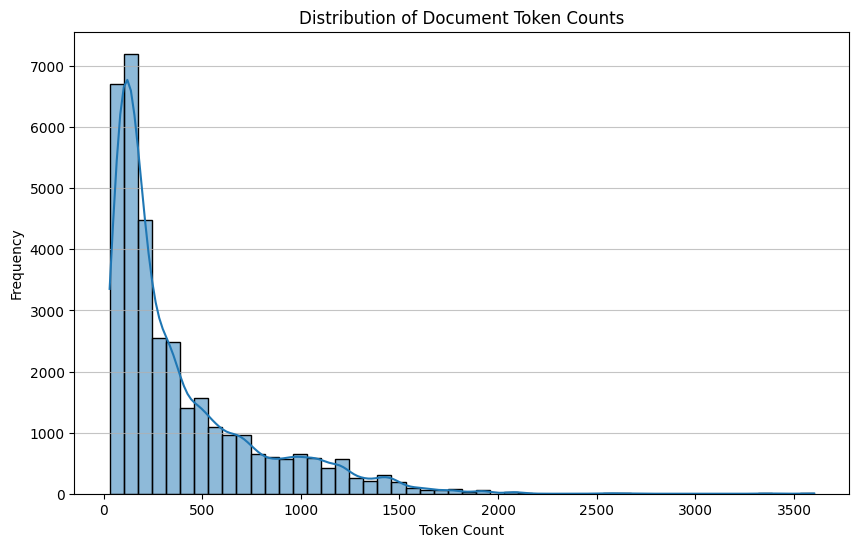

In [ ]:
# Plot __token_count as histogram
plt.figure(figsize=(10, 6))
sns.histplot(df['__token_count'], bins=50, kde=True)
plt.title('Distribution of Document Token Counts')
plt.xlabel('Token Count')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

In [33]:
reader = DataReader(jsonl_path)
df = reader.inspect_jsonl()


========== Inspecting JSONL: /content/drive/MyDrive/KLTN_Project/Datasets/vifc_queries_triples.jsonl ==========
Shape (Flattened Queries): (104583, 3)

--- Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104583 entries, 0 to 104582
Data columns (total 3 columns):
 #   Column      Non-Null Count   Dtype 
---  ------      --------------   ----- 
 0   id          104583 non-null  object
 1   type        104583 non-null  object
 2   query_text  104583 non-null  object
dtypes: object(3)
memory usage: 2.4+ MB

--- Head(10) ---
  id      type                                         query_text
0  0   KEYWORD  Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyề...
1  0   NATURAL  Phó Thủ tướng Trần Hồng Hà đã chúc mừng những ...
2  0  SEMANTIC  Phó Thủ tướng Trần Hồng Hà biểu dương các đơn ...
3  1   KEYWORD        Tô Văn Hải chất thải rắn chôn lấp trái phép
4  1   NATURAL  Tô Văn Hải đã có hành vi gì liên quan đến việc...
5  1  SEMANTIC  Hành vi Tô Văn Hải đổ chất thải rắn và chôn lấ...

In [34]:
df

,id,type,query_text
0,0,KEYWORD,Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyề...
1,0,NATURAL,Phó Thủ tướng Trần Hồng Hà đã chúc mừng những ...
2,0,SEMANTIC,Phó Thủ tướng Trần Hồng Hà biểu dương các đơn ...
3,1,KEYWORD,Tô Văn Hải chất thải rắn chôn lấp trái phép
4,1,NATURAL,Tô Văn Hải đã có hành vi gì liên quan đến việc...
...,...,...,...
104578,34809,NATURAL,Hai cha con đến Truy Bác vào ngày nào?
104579,34809,SEMANTIC,Phụ tử đến Truy Bác khi nào?
104580,34810,KEYWORD,giáo viên Neha 24/8 hành hung học sinh
104581,34810,NATURAL,Giáo viên trường công lập Neha đã xúi giục học...


In [35]:
id_counts = df['id'].value_counts()
ids_more_than_3 = id_counts[id_counts > 3].index.tolist()

print(f"IDs appearing more than 3 times: {ids_more_than_3}")
print(f"Total number of such IDs: {len(ids_more_than_3)}")

IDs appearing more than 3 times: ['34746', '9041', '8522', '19821', '8601', '11568', '10913', '26362', '16225', '14883', '472', '28346', '7304', '28389', '26587', '8929', '29511', '8302', '12088', '10181', '18136', '29927', '21556', '29790', '5181', '31644', '29718', '31495', '20056', '32097', '26925', '28840', '21552', '23151', '20982']
Total number of such IDs: 35


In [36]:
csv_df = pd.read_csv(filename)

present_ids = set(csv_df['id'].unique())

# Define the full range of expected IDs
all_expected_ids = set(range(0, 34811)) # Range is exclusive at the end, so 34810 is included.

# Find the IDs that are in the expected range but not in the present IDs
missing_ids = sorted(list(all_expected_ids - present_ids))

print(f"Number of missing IDs: {len(missing_ids)}")
print(f"Missing IDs: {missing_ids}")

Number of missing IDs: 0
Missing IDs: []


In [39]:
id_counts[id_counts > 3]

,count
id,
34746,9
9041,9
8522,9
19821,9
8601,9
11568,9
10913,9
26362,9
16225,9


In [41]:
df[df['id'] == '34746']

,id,type,query_text
104382,34746,KEYWORD,bạch hầu lây nhiễm vật trung gian
104383,34746,KEYWORD,bạch hầu thời gian truyền nhiễm
104384,34746,KEYWORD,bạch hầu tiếp xúc lây bệnh
104385,34746,NATURAL,Khi nào người mắc bệnh bạch hầu có thể bắt đầu...
104386,34746,NATURAL,Bệnh bạch hầu lây truyền qua những vật trung g...
104387,34746,NATURAL,Bệnh bạch hầu có lây truyền qua tiếp xúc với v...
104388,34746,SEMANTIC,bạch hầu lây lan qua vật phẩm dính huyết dịch
104389,34746,SEMANTIC,bệnh nhân bạch hầu có thể lây bệnh sau thất nhật
104390,34746,SEMANTIC,bệnh bạch hầu lây nhiễm qua vật thể chứa dịch ...


# DeeperImpact training data

In [ ]:
import pandas as pd
import json

In [ ]:
dataset_path = "/content/drive/MyDrive/KLTN_Project/Datasets"
tokenized_queries = f"{dataset_path}/vn_mining/queries_pretokenized.jsonl"
tokenized_docs = f"{dataset_path}/vn_mining/corpus_pretokenized.jsonl"
queries = f"{dataset_path}/deeperimpact/train_queries.tsv"
docs = f"{dataset_path}/deeperimpact/gemini_expanded_documents.tsv"

In [ ]:
doc_df = pd.read_csv(docs, sep='\t', header=None)
doc_df.head()

,0,1
0,0,"(Chinhphu.vn) - Đây là mong muốn, gửi gắm của ..."
1,1,"Ngày 24/3, Cơ quan Cảnh sát điều tra Công an t..."
2,2,(PLO)- Theo Tổng Công ty Cấp nước Sài Gòn (SAW...
3,3,"Với khoảng 200 thành viên, UEF Warm Hugs Club ..."
4,4,"Đi qua 2 năm dịch bệnh đầy thử thách, nhưng ch..."


In [ ]:
print(doc_df[1][0])

(Chinhphu.vn) - Đây là mong muốn, gửi gắm của Phó Thủ tướng Trần Hồng Hà đến những người làm truyền hình tại lễ bế mạc Liên hoan Truyền hình toàn quốc lần thứ 41, tối 18/3, tại TP. Hải Phòng. Phó Thủ tướng Trần Hồng Hà: Các tác phẩm truyền hình đã vun đắp, làm giàu cho nền văn hóa Việt Nam tiên tiến, đậm đà bản sắc dân tộc, góp phần tạo dựng môi trường văn hóa lành mạnh và xây dựng con người Việt Nam nhân cách, trách nhiệm, hội nhập - Ảnh: VGP/Minh Khôi Tham dự lễ bế mạc còn có Bí thư Trung ương Đảng, Trưởng Ban Tuyên giáo Trung ương Nguyễn Trọng Nghĩa, lãnh đạo các bộ, ngành Trung ương, địa phương, đại diện các đài truyền hình, đơn vị sản xuất chương trình truyền hình, cùng đông đảo cán bộ, phóng viên, biên tập viên, nghệ sĩ, diễn viên hoạt động trong lĩnh vực truyền hình... Thay mặt Chính phủ, Thủ tướng Chính phủ, Phó Thủ tướng Trần Hồng Hà chúc mừng Đài Truyền hình Việt Nam, Đài truyền hình các tỉnh, thành phố trên cả nước, các đơn vị sản xuất truyền hình và TP. Hải Phòng đã tổ chức

In [ ]:
doc_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3028 entries, 0 to 3027
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       3028 non-null   int64 
 1   1       3028 non-null   object
dtypes: int64(1), object(1)
memory usage: 47.4+ KB


In [ ]:
doc_df[0].nunique()

3028

In [ ]:
doc_df[1].nunique()

3028

In [ ]:
query_df = pd.read_csv(queries, sep='\t', header=None)
query_df.head()

,0,1
0,0,"Phó Thủ tướng Trần Hồng Hà thay mặt Chính phủ,..."
1,1,Hành vi của Tô Văn Hải là cho phép người khác ...
2,2,SAWACO thông báo tạm ngưng cung cấp nước để th...
3,3,"CLB luôn chuẩn bị rất kỹ lưỡng, chỉn chu chươn..."
4,4,"ILA tiếp nhận và hỗ trợ học sinh miễn phí, Bé ..."


In [ ]:
query_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125581 entries, 0 to 125580
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   0       125581 non-null  int64 
 1   1       125581 non-null  object
dtypes: int64(1), object(1)
memory usage: 1.9+ MB


In [ ]:
query_df[query_df[0] == '102305']

,0,1
